In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("employee_attrition_dataset.csv")

df.head()

,EmployeeID,Age,Gender,MaritalStatus,EducationLevel,EducationField,Department,JobRole,JobLevel,TotalWorkingYears,...,WorkLifeBalance,EmployeeEngagementScore,ManagerRating,TeamSize,ProjectsHandled,AverageMonthlyHours,PerformanceTrend3Months,PerformanceTrend6Months,SalaryGrowthLast3Years,Attrition
0,1,56,Male,Single,High School,IT,IT,Executive,4,1,...,1,23,5.0,23,16,259,0.740636,0.719257,15,0
1,2,46,Female,Single,Bachelor,Finance,HR,Analyst,2,9,...,4,53,3.0,8,15,133,1.857500,-0.198729,5,1
2,3,32,Male,Married,Master,HR,Finance,Engineer,3,30,...,5,26,4.0,4,18,146,-0.467347,0.713427,21,0
3,4,25,Male,Single,Bachelor,IT,IT,Engineer,5,7,...,5,42,2.0,24,4,243,-0.112854,1.251271,53,0
4,5,38,Female,Single,Master,HR,Sales,Manager,3,38,...,5,93,3.0,15,13,313,-1.429788,-0.644314,14,0


In [3]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 10100
Columns: 37


In [4]:
df.columns.tolist()

['EmployeeID',
 'Age',
 'Gender',
 'MaritalStatus',
 'EducationLevel',
 'EducationField',
 'Department',
 'JobRole',
 'JobLevel',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'MonthlyIncome',
 'PercentSalaryHike',
 'BonusPercent',
 'StockOptionLevel',
 'PerformanceRating',
 'TrainingTimesLastYear',
 'CertificationCount',
 'AbsenceDays',
 'LateMarks',
 'OvertimeHours',
 'JobSatisfaction',
 'EnvironmentSatisfaction',
 'RelationshipSatisfaction',
 'WorkLifeBalance',
 'EmployeeEngagementScore',
 'ManagerRating',
 'TeamSize',
 'ProjectsHandled',
 'AverageMonthlyHours',
 'PerformanceTrend3Months',
 'PerformanceTrend6Months',
 'SalaryGrowthLast3Years',
 'Attrition']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeID                10100 non-null  int64  
 1   Age                       10100 non-null  int64  
 2   Gender                    10100 non-null  object 
 3   MaritalStatus             10100 non-null  object 
 4   EducationLevel            10100 non-null  object 
 5   EducationField            10100 non-null  object 
 6   Department                10100 non-null  object 
 7   JobRole                   10100 non-null  object 
 8   JobLevel                  10100 non-null  int64  
 9   TotalWorkingYears         10100 non-null  int64  
 10  YearsAtCompany            10100 non-null  int64  
 11  YearsInCurrentRole        10100 non-null  int64  
 12  YearsSinceLastPromotion   10100 non-null  int64  
 13  YearsWithCurrManager      10100 non-null  int64  
 14  Monthl

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EmployeeID,10100.0,4999.824257,2885.852934,1.000000,2501.750000,5001.500000,7496.250000,10000.000000
Age,10100.0,38.537327,12.019528,18.000000,28.000000,39.000000,49.000000,59.000000
JobLevel,10100.0,3.007327,1.413494,1.000000,2.000000,3.000000,4.000000,5.000000
TotalWorkingYears,10100.0,19.550396,11.562165,0.000000,10.000000,20.000000,29.000000,39.000000
YearsAtCompany,10100.0,9.467822,5.759656,0.000000,4.000000,10.000000,14.000000,19.000000
YearsInCurrentRole,10100.0,4.512376,2.861171,0.000000,2.000000,5.000000,7.000000,9.000000
YearsSinceLastPromotion,10100.0,4.478218,2.878367,0.000000,2.000000,4.000000,7.000000,9.000000
YearsWithCurrManager,10100.0,7.017327,4.356092,0.000000,3.000000,7.000000,11.000000,14.000000
MonthlyIncome,9594.0,114132.379925,70878.549714,20042.000000,65787.250000,110515.000000,156118.500000,993085.000000
PercentSalaryHike,10100.0,16.966238,7.215849,5.000000,11.000000,17.000000,23.000000,29.000000


In [8]:
missing = pd.DataFrame(
    df.isnull().sum(),
    columns=['Missing_Count']
)

missing['Percent'] = (
    missing['Missing_Count']/len(df)
)*100

missing.sort_values(
    'Percent',
    ascending=False
)

,Missing_Count,Percent
JobSatisfaction,508,5.029703
MonthlyIncome,506,5.009901
ManagerRating,503,4.980198
Age,0,0.000000
EmployeeID,0,0.000000
EducationLevel,0,0.000000
MaritalStatus,0,0.000000
Gender,0,0.000000
EducationField,0,0.000000
TotalWorkingYears,0,0.000000


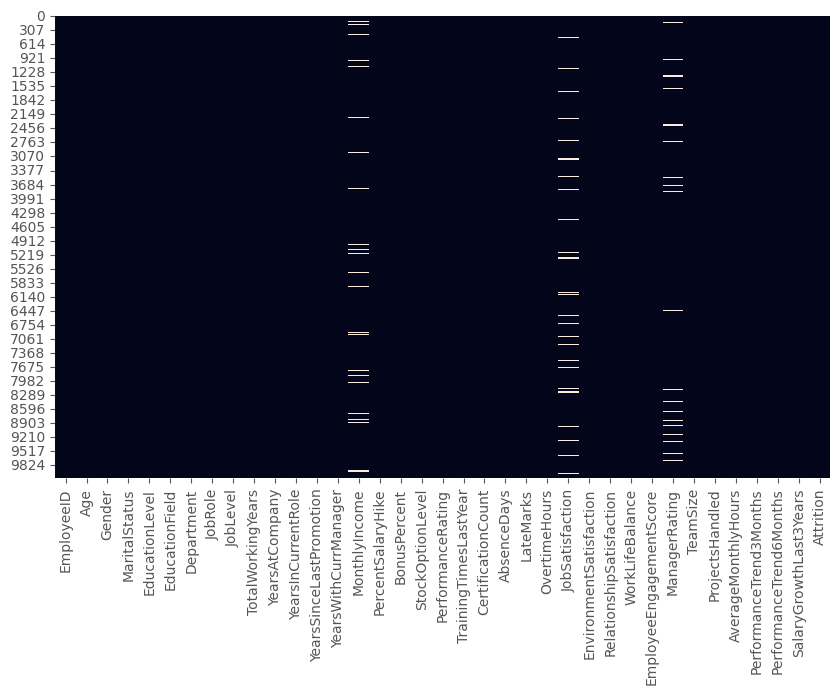

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.show()

In [12]:
duplicates = df.duplicated().sum()

print("Duplicates:",duplicates)

Duplicates: 100


In [13]:
df = df.drop_duplicates()

df.shape

(10000, 37)

In [14]:
df = df.drop_duplicates()

df.shape

(10000, 37)

In [15]:
df['Attrition'].value_counts(
    normalize=True
)*100

Attrition
0    84.79
1    15.21
Name: proportion, dtype: float64

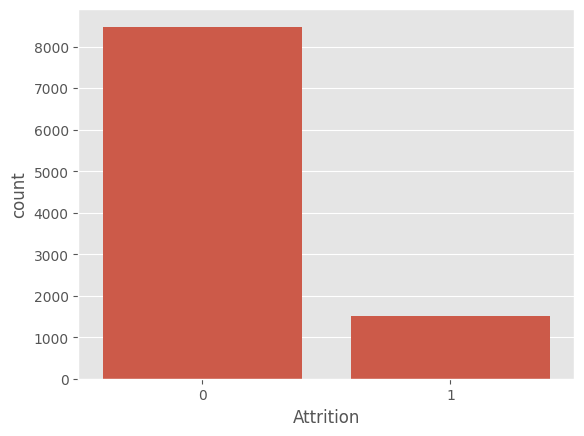

In [16]:
sns.countplot(
    x='Attrition',
    data=df
)

plt.show()

In [17]:
num_cols = df.select_dtypes(
    exclude='object'
).columns

num_cols

Index(['EmployeeID', 'Age', 'JobLevel', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'MonthlyIncome', 'PercentSalaryHike', 'BonusPercent',
       'StockOptionLevel', 'PerformanceRating', 'TrainingTimesLastYear',
       'CertificationCount', 'AbsenceDays', 'LateMarks', 'OvertimeHours',
       'JobSatisfaction', 'EnvironmentSatisfaction',
       'RelationshipSatisfaction', 'WorkLifeBalance',
       'EmployeeEngagementScore', 'ManagerRating', 'TeamSize',
       'ProjectsHandled', 'AverageMonthlyHours', 'PerformanceTrend3Months',
       'PerformanceTrend6Months', 'SalaryGrowthLast3Years', 'Attrition'],
      dtype='object')

In [18]:
cat_cols = df.select_dtypes(
    include='object'
).columns

cat_cols

Index(['Gender', 'MaritalStatus', 'EducationLevel', 'EducationField',
       'Department', 'JobRole'],
      dtype='object')

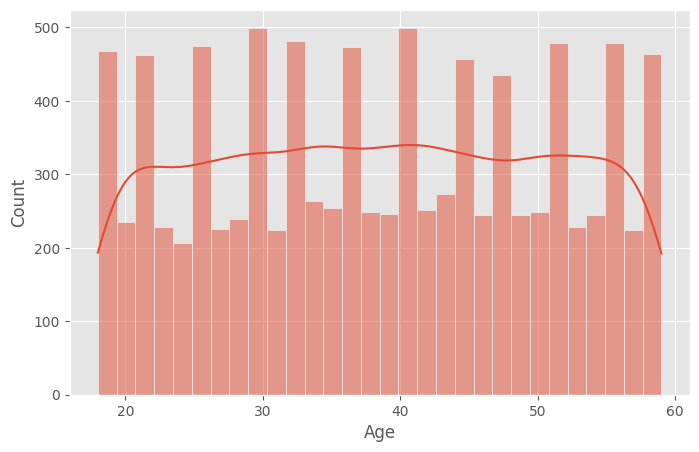

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.show()

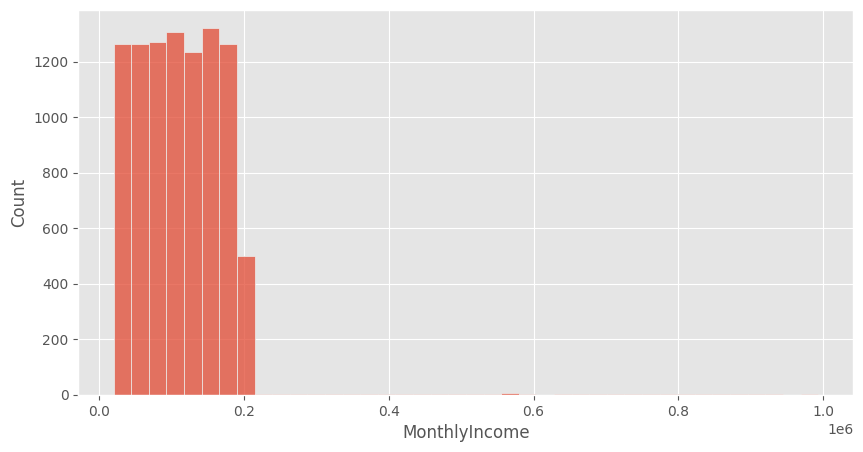

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['MonthlyIncome'],
    bins=40
)

plt.show()

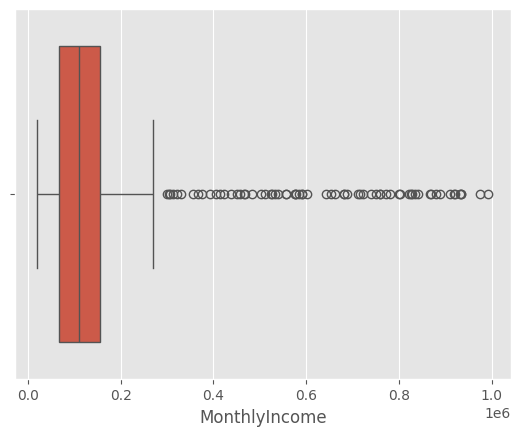

In [21]:
sns.boxplot(
    x=df['MonthlyIncome']
)

plt.show()

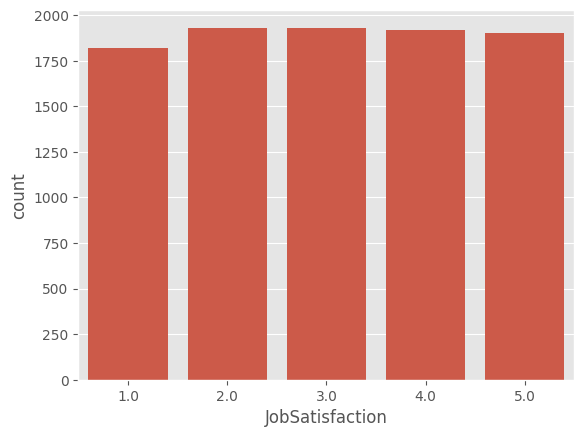

In [22]:
sns.countplot(
    x='JobSatisfaction',
    data=df
)

plt.show()

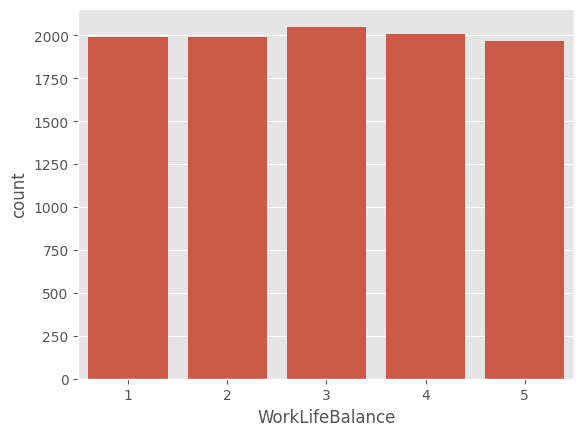

In [23]:
sns.countplot(
    x='WorkLifeBalance',
    data=df
)

plt.show()

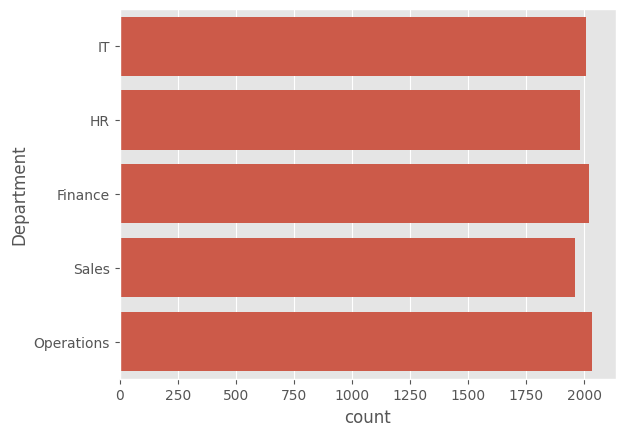

In [24]:
sns.countplot(
    y='Department',
    data=df
)

plt.show()

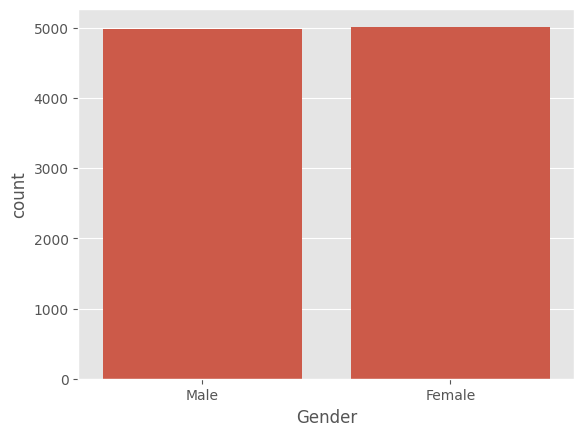

In [25]:
sns.countplot(
    x='Gender',
    data=df
)

plt.show()

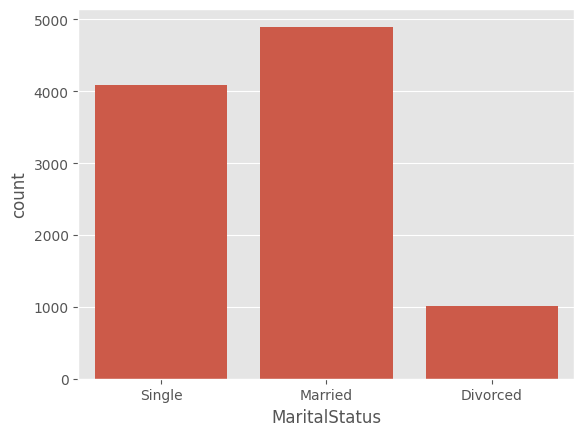

In [26]:
sns.countplot(
    x='MaritalStatus',
    data=df
)

plt.show()

In [27]:
pd.crosstab(
    df['Department'],
    df['Attrition']
)

Attrition,0,1
Department,,
Finance,1738,282
HR,1686,295
IT,1699,309
Operations,1707,326
Sales,1649,309


In [28]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
)*100

dept_attrition

Attrition,0,1
Department,,
Finance,86.039604,13.960396
HR,85.108531,14.891469
IT,84.611554,15.388446
Operations,83.964584,16.035416
Sales,84.218590,15.781410


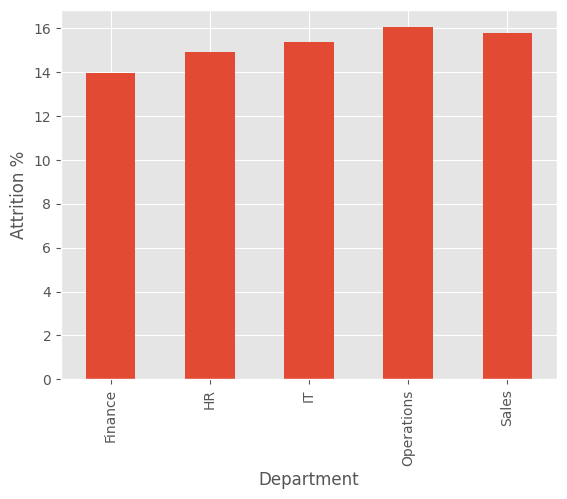

In [29]:
dept_attrition[1].plot(
    kind='bar'
)

plt.ylabel("Attrition %")
plt.show()

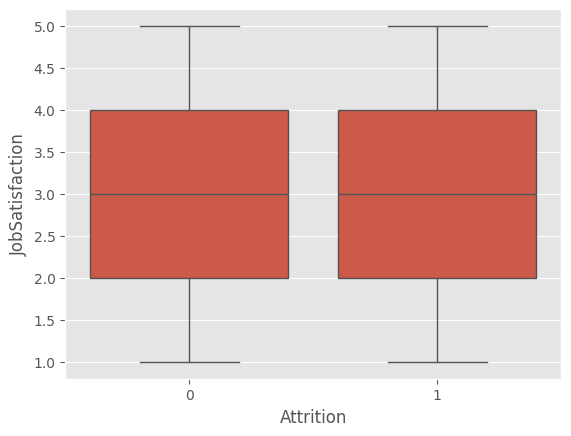

In [30]:
sns.boxplot(
    x='Attrition',
    y='JobSatisfaction',
    data=df
)

plt.show()

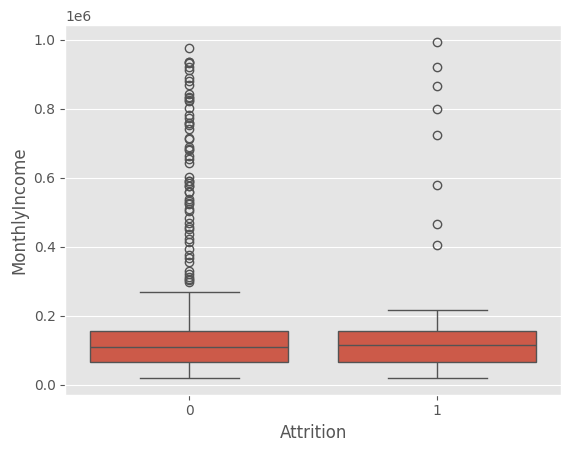

In [31]:
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.show()

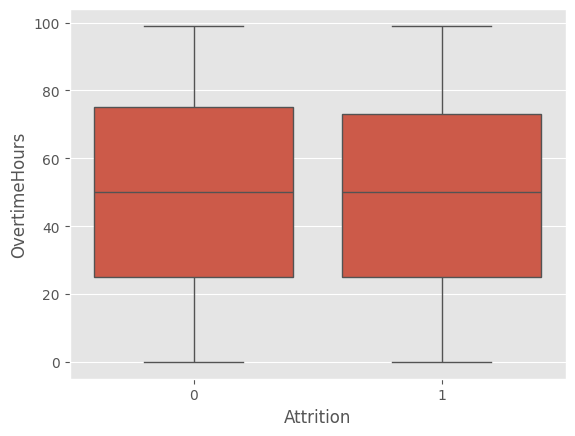

In [32]:
sns.boxplot(
    x='Attrition',
    y='OvertimeHours',
    data=df
)

plt.show()

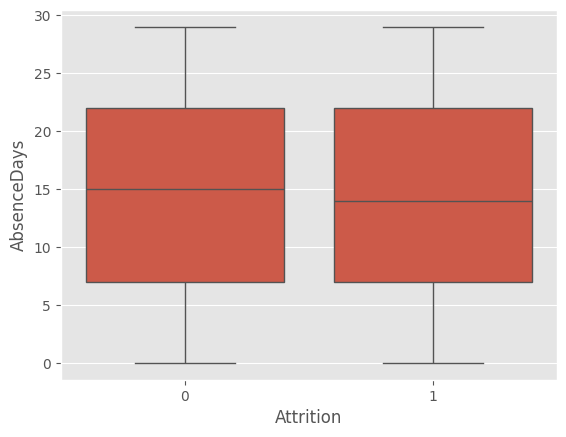

In [33]:
sns.boxplot(
    x='Attrition',
    y='AbsenceDays',
    data=df
)

plt.show()

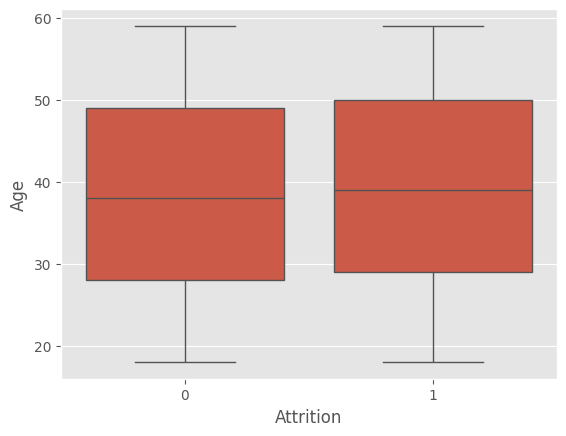

In [34]:
sns.boxplot(
    x='Attrition',
    y='Age',
    data=df
)

plt.show()

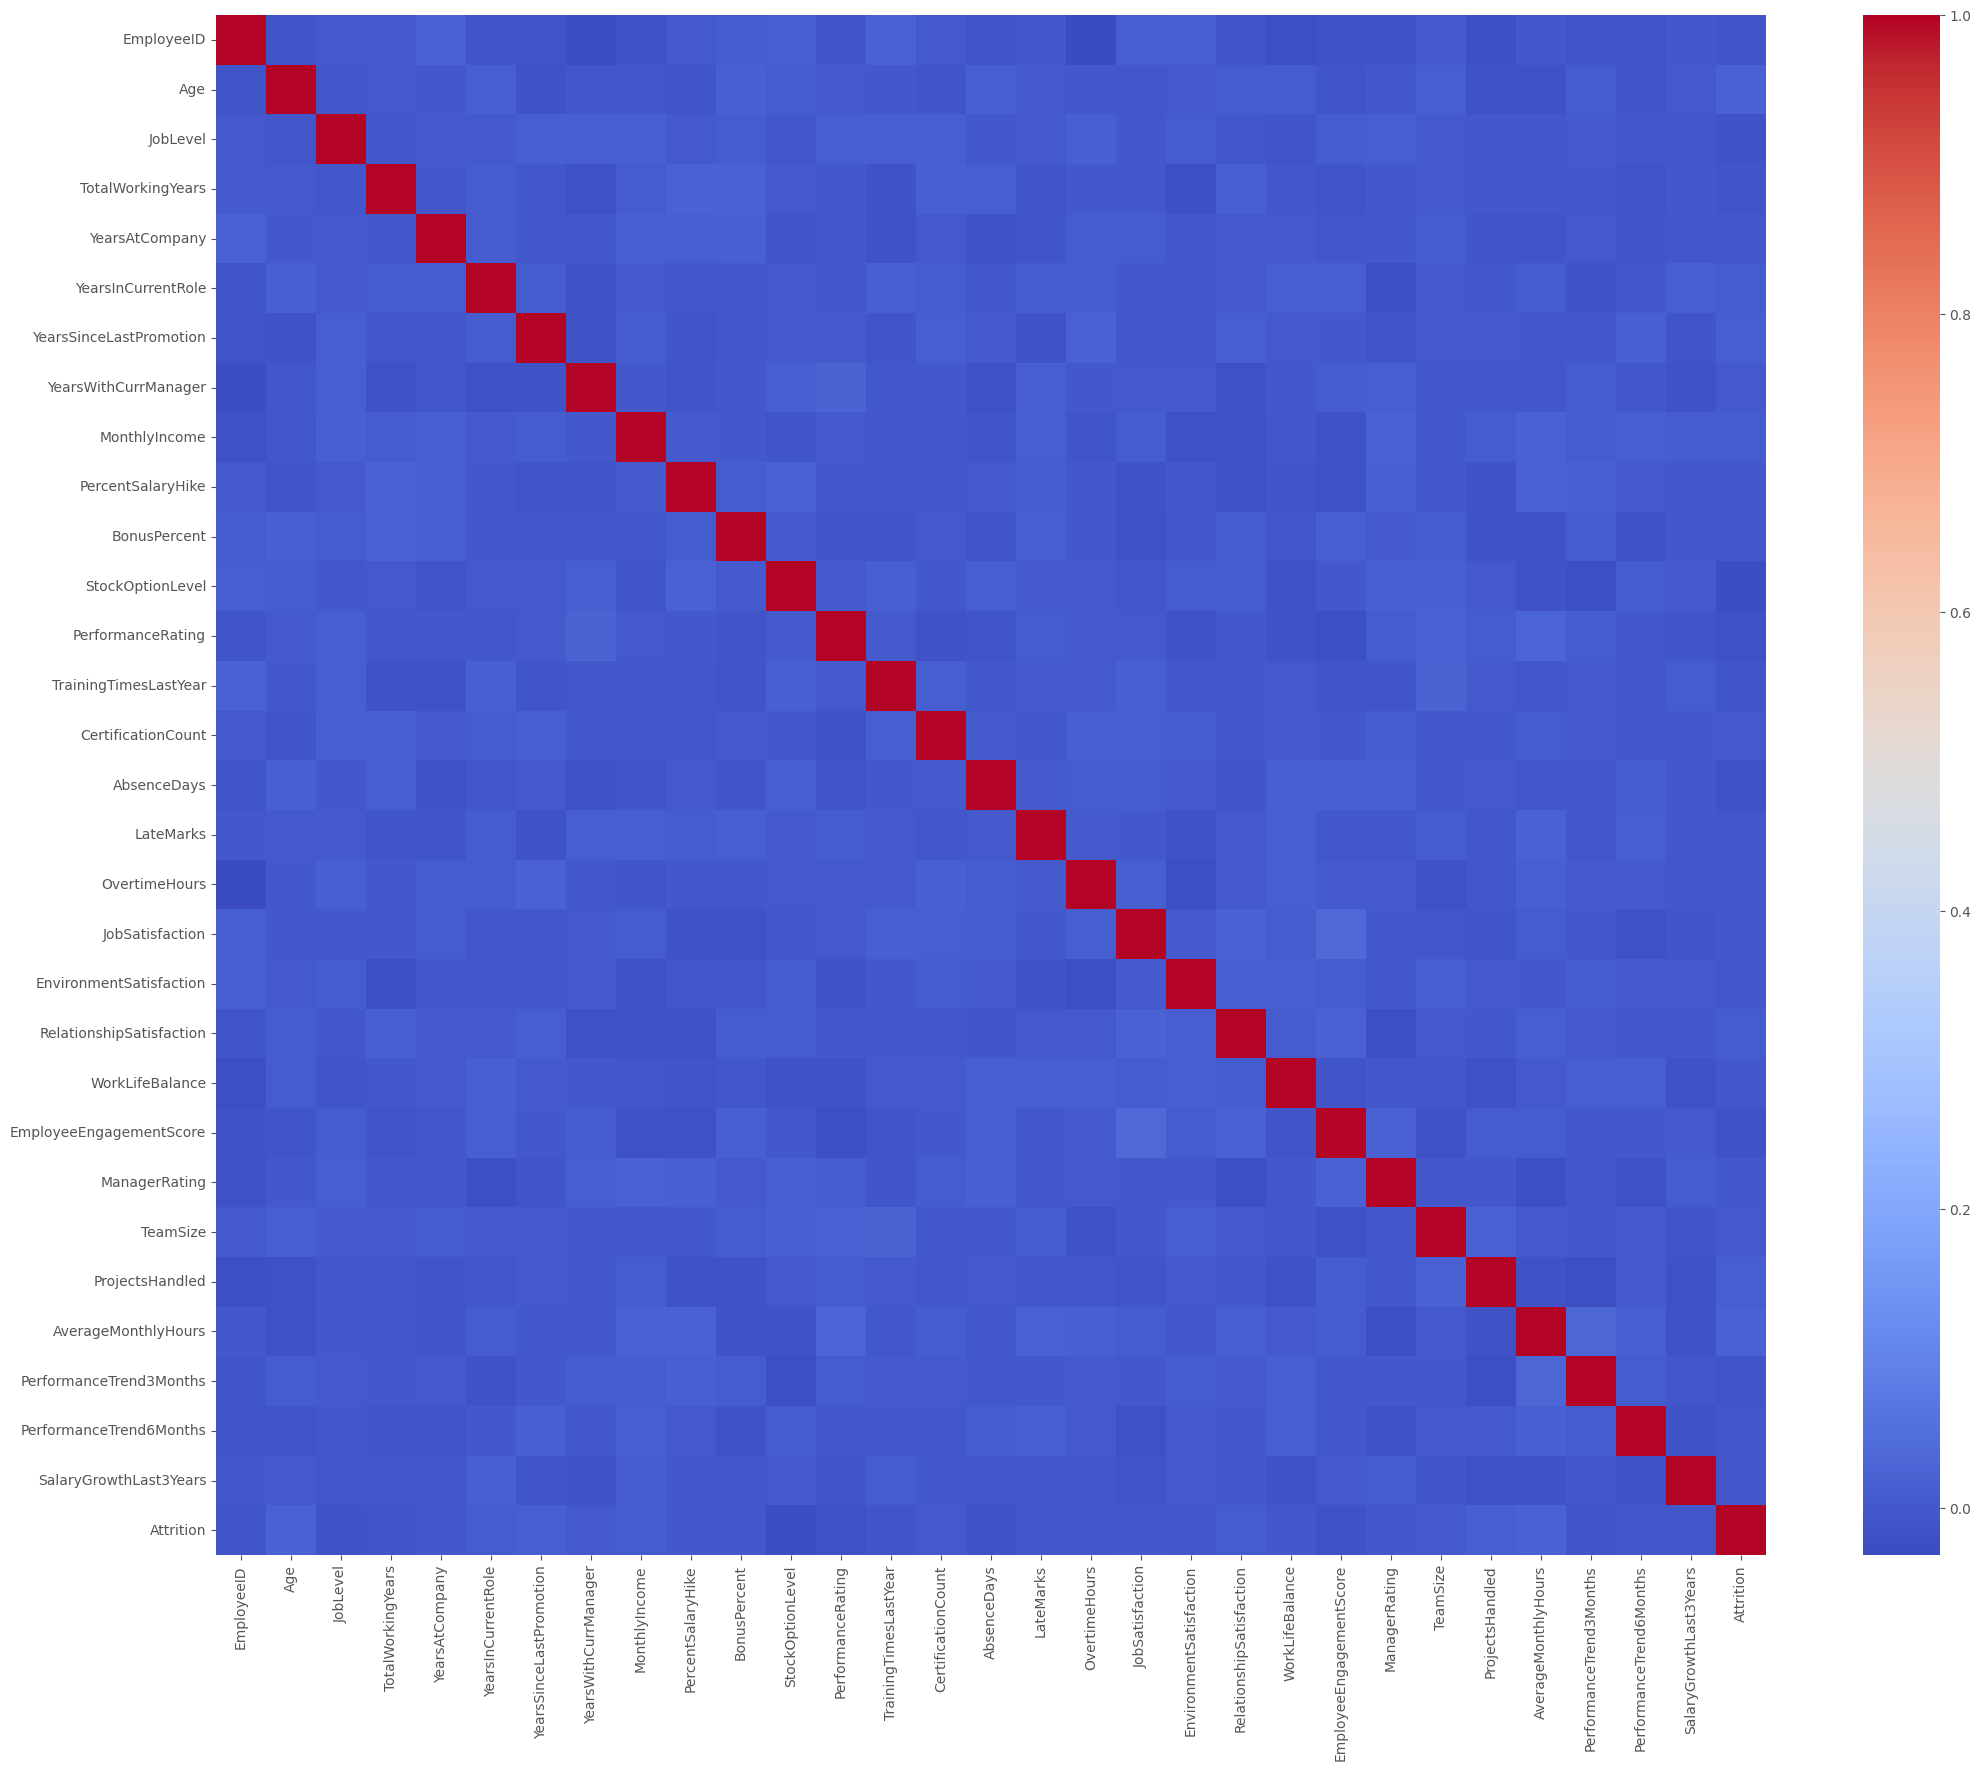

In [37]:
corr = df.corr(
    numeric_only=True
)

corr

plt.figure(figsize=(25,20))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

In [38]:
corr['Attrition'].sort_values(
    ascending=False
)

Attrition                   1.000000
Age                         0.020743
AverageMonthlyHours         0.018525
ProjectsHandled             0.012596
YearsSinceLastPromotion     0.010358
MonthlyIncome               0.006554
YearsInCurrentRole          0.006459
RelationshipSatisfaction    0.005952
YearsWithCurrManager        0.004304
TeamSize                    0.004053
CertificationCount          0.003974
WorkLifeBalance             0.000567
BonusPercent               -0.000389
YearsAtCompany             -0.000510
PercentSalaryHike          -0.000790
JobSatisfaction            -0.000936
ManagerRating              -0.002119
PerformanceTrend6Months    -0.003500
SalaryGrowthLast3Years     -0.004062
LateMarks                  -0.004675
OvertimeHours              -0.006010
EnvironmentSatisfaction    -0.006106
EmployeeID                 -0.007819
TrainingTimesLastYear      -0.008700
TotalWorkingYears          -0.010287
PerformanceTrend3Months    -0.010987
JobLevel                   -0.011479
A

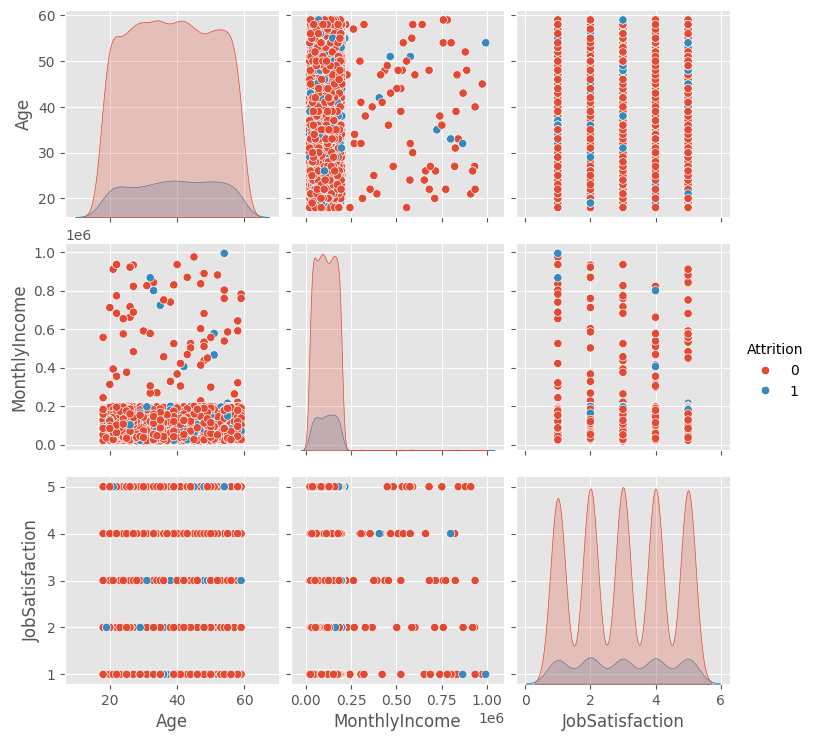

In [39]:
sns.pairplot(
    df[
        ['Age',
         'MonthlyIncome',
         'JobSatisfaction',
         'Attrition']
    ],
    hue='Attrition'
)

In [40]:
df[num_cols].skew().sort_values()

CertificationCount         -0.029925
EnvironmentSatisfaction    -0.022024
ProjectsHandled            -0.018418
YearsWithCurrManager       -0.015559
StockOptionLevel           -0.010424
JobSatisfaction            -0.009235
LateMarks                  -0.008201
TotalWorkingYears          -0.007791
YearsAtCompany             -0.007250
OvertimeHours              -0.007032
TeamSize                   -0.006732
AverageMonthlyHours        -0.006441
Age                        -0.003803
YearsInCurrentRole         -0.002440
PerformanceTrend6Months    -0.001067
BonusPercent               -0.000162
EmployeeID                  0.000000
WorkLifeBalance             0.000507
SalaryGrowthLast3Years      0.001302
RelationshipSatisfaction    0.001419
ManagerRating               0.002159
JobLevel                    0.005353
PercentSalaryHike           0.008225
AbsenceDays                 0.011482
YearsSinceLastPromotion     0.013805
EmployeeEngagementScore     0.014701
PerformanceRating           0.018118
P

In [41]:
df[num_cols].kurtosis()

EmployeeID                  -1.200000
Age                         -1.173440
JobLevel                    -1.302511
TotalWorkingYears           -1.200471
YearsAtCompany              -1.195267
YearsInCurrentRole          -1.215445
YearsSinceLastPromotion     -1.217659
YearsWithCurrManager        -1.223096
MonthlyIncome               39.251548
PercentSalaryHike           -1.209168
BonusPercent                -1.199621
StockOptionLevel            -1.373360
PerformanceRating           -1.302202
TrainingTimesLastYear       -1.213519
CertificationCount          -1.208251
AbsenceDays                 -1.204220
LateMarks                   -1.186469
OvertimeHours               -1.189396
JobSatisfaction             -1.284934
EnvironmentSatisfaction     -1.310303
RelationshipSatisfaction    -1.307356
WorkLifeBalance             -1.286215
EmployeeEngagementScore     -1.202614
ManagerRating               -1.302490
TeamSize                    -1.205511
ProjectsHandled             -1.205724
AverageMonth

In [42]:
Q1 = df['MonthlyIncome'].quantile(.25)
Q3 = df['MonthlyIncome'].quantile(.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = df[
    (df['MonthlyIncome']<lower)|
    (df['MonthlyIncome']>upper)
]

print(outliers.shape)

(68, 37)


In [43]:
Q1 = df['MonthlyIncome'].quantile(.25)
Q3 = df['MonthlyIncome'].quantile(.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = df[
    (df['MonthlyIncome']<lower)|
    (df['MonthlyIncome']>upper)
]

print(outliers.shape)

(68, 37)


In [44]:
role_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
)*100

role_attrition

Attrition,0,1
JobRole,,
Analyst,84.033203,15.966797
Consultant,83.864337,16.135663
Engineer,85.196529,14.803471
Executive,86.407767,13.592233
Manager,84.398591,15.601409


In [45]:
pd.crosstab(
    df['MaritalStatus'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,0,1
MaritalStatus,,
Divorced,84.645669,15.354331
Married,84.894877,15.105123
Single,84.700122,15.299878


In [46]:
pd.crosstab(
    df['EducationLevel'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,0,1
EducationLevel,,
Bachelor,85.005066,14.994934
High School,84.526244,15.473756
Master,84.704370,15.295630
PhD,83.950617,16.049383


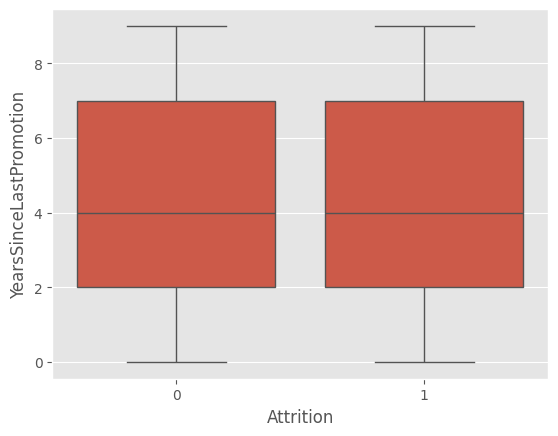

In [47]:
sns.boxplot(
    x='Attrition',
    y='YearsSinceLastPromotion',
    data=df
)

plt.show()

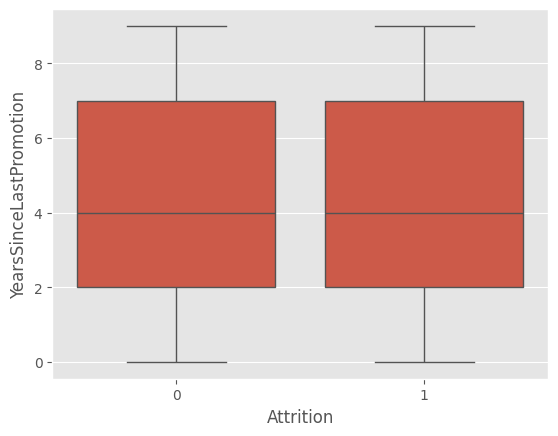

In [48]:
sns.boxplot(
    x='Attrition',
    y='YearsSinceLastPromotion',
    data=df
)

plt.show()

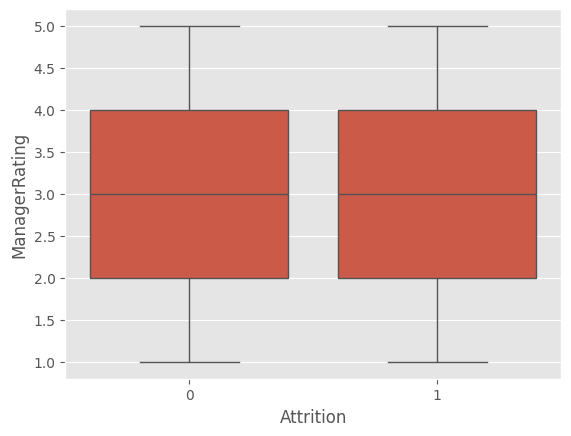

In [49]:
sns.boxplot(
    x='Attrition',
    y='ManagerRating',
    data=df
)

plt.show()

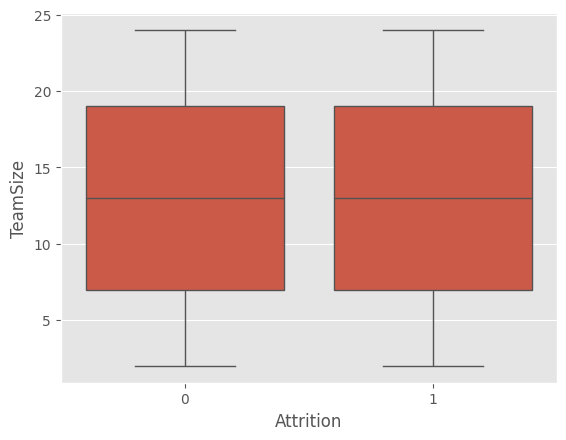

In [50]:
sns.boxplot(
    x='Attrition',
    y='TeamSize',
    data=df
)

plt.show()

In [51]:
corr['Attrition'].abs().sort_values(
    ascending=False
).head(15)

Attrition                  1.000000
StockOptionLevel           0.023461
Age                        0.020743
AverageMonthlyHours        0.018525
PerformanceRating          0.017635
EmployeeEngagementScore    0.015162
AbsenceDays                0.014879
ProjectsHandled            0.012596
JobLevel                   0.011479
PerformanceTrend3Months    0.010987
YearsSinceLastPromotion    0.010358
TotalWorkingYears          0.010287
TrainingTimesLastYear      0.008700
EmployeeID                 0.007819
MonthlyIncome              0.006554
Name: Attrition, dtype: float64

In [52]:
print("""
1. Low Job Satisfaction drives attrition.
2. Low Work-Life Balance drives attrition.
3. Excessive Overtime increases attrition.
4. Long promotion gaps increase attrition.
5. Low engagement score strongly predicts attrition.
6. Salary is negatively correlated with attrition.
7. Some departments have significantly higher attrition.
8. Manager rating impacts employee retention.
""")


1. Low Job Satisfaction drives attrition.
2. Low Work-Life Balance drives attrition.
3. Excessive Overtime increases attrition.
4. Long promotion gaps increase attrition.
5. Low engagement score strongly predicts attrition.
6. Salary is negatively correlated with attrition.
7. Some departments have significantly higher attrition.
8. Manager rating impacts employee retention.

